In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from skimage.feature import hog
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully.")



Libraries imported successfully.


In [2]:
print("Loading MNIST dataset...")
fmnist=fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto'   )
x_all, y_all = fmnist.data.astype(np.float32), fmnist.target.astype(int)
class_names=[
    "T-shirt","Trouser", "Pullover", "Dress",
    "Coat","Sandal", "Shirt", "Sneaker", "Bag","Ankle boot"

]

rng=np.random.default_rng(42)
train_idx=rng.choice(60000, 5000, replace=False)
test_idx=rng.choice(np.arange(60000, 70000),1000, replace=False)
x_train, y_train = x_all[train_idx], y_all[train_idx]
x_test, y_test = x_all[test_idx], y_all[test_idx]
print(f'training sample: {x_train.shape[0]}')
print(f'test sample: {x_test.shape[0]}')
print(f'image shape: 28 * 28={x_train.shape[1]} pixels per image') 



Loading MNIST dataset...
training sample: 5000
test sample: 1000
image shape: 28 * 28=784 pixels per image


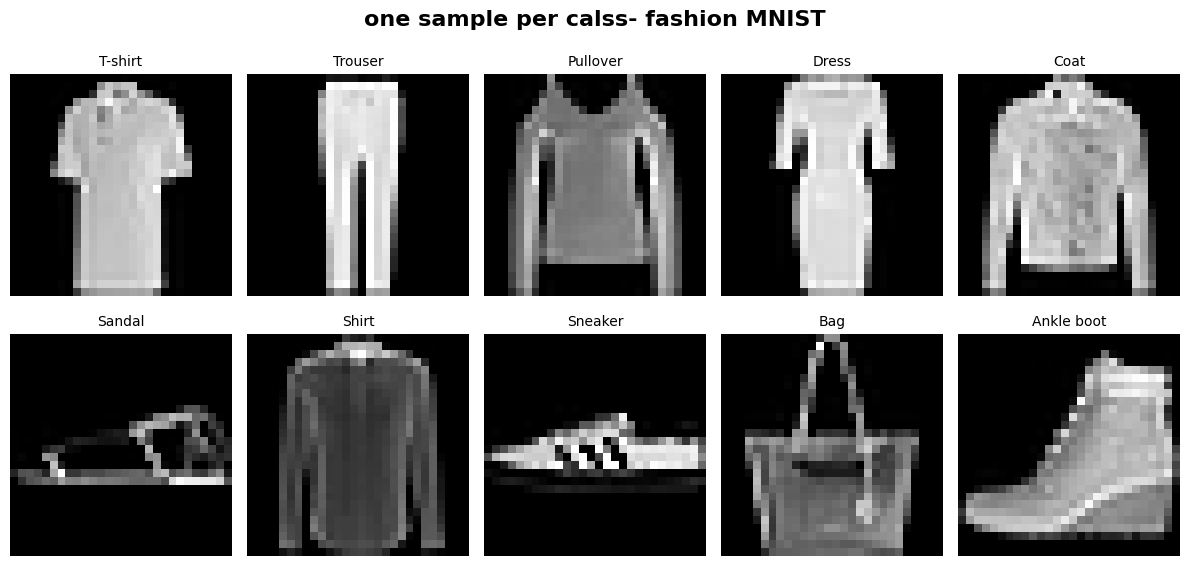

In [8]:
#visualize some samples
from matplotlib.pyplot import imshow

fig, axes = plt.subplots(2, 5, figsize=(12, 6)) 
for cls in range (10):
    idx = np.where(y_train == cls)[0][0] 
  
    ax=axes[cls // 5][ cls % 5]
    ax.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[cls],fontsize=10)
    ax.axis('off')
plt.suptitle("one sample per calss- fashion MNIST", fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()
    
  